In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

# Load all datasets
df_main = pd.read_csv('dataset/dataset.csv')
df_symptom2disease = pd.read_csv('dataset/Symptom2Disease.csv')
df_training = pd.read_csv('dataset/Training.csv')

print("Main Dataset Shape:", df_main.shape)
print("Symptom2Disease Shape:", df_symptom2disease.shape)
print("Training Shape:", df_training.shape)

print("\nMain Columns:", df_main.columns.tolist())
print("Symptom2Disease Columns:", df_symptom2disease.columns.tolist())
print("Training Columns:", df_training.columns.tolist()[:5], "...")

Main Dataset Shape: (4920, 18)
Symptom2Disease Shape: (1200, 3)
Training Shape: (4920, 134)

Main Columns: ['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4', 'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16', 'Symptom_17']
Symptom2Disease Columns: ['Unnamed: 0', 'label', 'text']
Training Columns: ['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering'] ...


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\iamsu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# Fix underscores in main dataset
df_main['symptoms_text'] = df_main[
    ['Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4',
     'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8',
     'Symptom_9', 'Symptom_10', 'Symptom_11', 'Symptom_12',
     'Symptom_13', 'Symptom_14', 'Symptom_15', 'Symptom_16',
     'Symptom_17']
].fillna('').apply(
    lambda row: ' '.join(
        val.strip().replace('_', ' ')
        for val in row.values.astype(str) if val.strip() != ''
    ), axis=1
)

department_mapping = {
    'Fungal infection': 'DERMATOLOGY',
    'Allergy': 'DERMATOLOGY',
    'Drug Reaction': 'DERMATOLOGY',
    'Psoriasis': 'DERMATOLOGY',
    'Impetigo': 'DERMATOLOGY',
    'Acne': 'DERMATOLOGY',
    'GERD': 'GASTROENTEROLOGY',
    'Chronic cholestasis': 'GASTROENTEROLOGY',
    'Peptic ulcer diseae': 'GASTROENTEROLOGY',
    'Gastroenteritis': 'GASTROENTEROLOGY',
    'Hepatitis A': 'GASTROENTEROLOGY',
    'Hepatitis B': 'GASTROENTEROLOGY',
    'Hepatitis C': 'GASTROENTEROLOGY',
    'Hepatitis D': 'GASTROENTEROLOGY',
    'Hepatitis E': 'GASTROENTEROLOGY',
    'Alcoholic hepatitis': 'GASTROENTEROLOGY',
    'Jaundice': 'GASTROENTEROLOGY',
    'Malaria': 'INFECTIOUS DISEASE',
    'Chicken pox': 'INFECTIOUS DISEASE',
    'Dengue': 'INFECTIOUS DISEASE',
    'Typhoid': 'INFECTIOUS DISEASE',
    'tuberculosis': 'INFECTIOUS DISEASE',
    'Common Cold': 'INFECTIOUS DISEASE',
    'AIDS': 'INFECTIOUS DISEASE',
    'Diabetes ': 'ENDOCRINOLOGY',
    'Hypoglycemia': 'ENDOCRINOLOGY',
    'Hyperthyroidism': 'ENDOCRINOLOGY',
    'Hypothyroidism': 'ENDOCRINOLOGY',
    'Hypertension ': 'CARDIOLOGY',
    'Heart attack': 'CARDIOLOGY',
    'Bronchial Asthma': 'PULMONOLOGY',
    'Pneumonia': 'PULMONOLOGY',
    'Urinary tract infection': 'UROLOGY',
    'Dimorphic hemmorhoids(piles)': 'UROLOGY',
    'Arthritis': 'ORTHOPEDICS',
    'Osteoarthristis': 'ORTHOPEDICS',
    'Cervical spondylosis': 'ORTHOPEDICS',
    'Migraine': 'NEUROLOGY',
    'Paralysis (brain hemorrhage)': 'NEUROLOGY',
    'Varicose veins': 'NEUROLOGY',
}

df_main['department'] = df_main['Disease'].map(department_mapping)
df_main = df_main.dropna(subset=['department'])
df_main_final = df_main[['symptoms_text', 'department']].copy()
df_main_final.columns = ['text', 'label']

print("Main Dataset Ready:", df_main_final.shape)
print(df_main_final.head(2))

Main Dataset Ready: (4560, 2)
                                                text        label
0  itching skin rash nodal skin eruptions dischro...  DERMATOLOGY
1  skin rash nodal skin eruptions dischromic  pat...  DERMATOLOGY


In [3]:
print("Symptom2Disease sample:")
print(df_symptom2disease.head(3))
print("\nUnique diseases:", df_symptom2disease['label'].nunique())
print(df_symptom2disease['label'].value_counts())
# Map Symptom2Disease to departments
symptom2disease_mapping = {
    'Psoriasis': 'DERMATOLOGY',
    'Varicose Veins': 'NEUROLOGY',
    'Typhoid': 'INFECTIOUS DISEASE',
    'Chicken pox': 'INFECTIOUS DISEASE',
    'Impetigo': 'DERMATOLOGY',
    'Dengue': 'INFECTIOUS DISEASE',
    'Fungal infection': 'DERMATOLOGY',
    'Common Cold': 'INFECTIOUS DISEASE',
    'Pneumonia': 'PULMONOLOGY',
    'Dimorphic Hemorrhoids': 'UROLOGY',
    'Arthritis': 'ORTHOPEDICS',
    'Acne': 'DERMATOLOGY',
    'Bronchial Asthma': 'PULMONOLOGY',
    'Hypertension': 'CARDIOLOGY',
    'Migraine': 'NEUROLOGY',
    'Cervical spondylosis': 'ORTHOPEDICS',
    'Jaundice': 'GASTROENTEROLOGY',
    'Malaria': 'INFECTIOUS DISEASE',
    'urinary tract infection': 'UROLOGY',
    'Allergy': 'DERMATOLOGY',
    'Gastroenteritis': 'GASTROENTEROLOGY',
    'Drug Reaction': 'DERMATOLOGY',
    'Peptic ulcer disease': 'GASTROENTEROLOGY',
    'Diabetes': 'ENDOCRINOLOGY',
}

df_symptom2disease['department'] = df_symptom2disease['label'].map(
    symptom2disease_mapping)
df_symptom2disease = df_symptom2disease.dropna(subset=['department'])
df2_final = df_symptom2disease[['text', 'department']].copy()
df2_final.columns = ['text', 'label']

print("\nSymptom2Disease Ready:", df2_final.shape)
print(df2_final.head(2))

Symptom2Disease sample:
   Unnamed: 0      label                                               text
0           0  Psoriasis  I have been experiencing a skin rash on my arm...
1           1  Psoriasis  My skin has been peeling, especially on my kne...
2           2  Psoriasis  I have been experiencing joint pain in my fing...

Unique diseases: 24
label
Psoriasis                          50
Varicose Veins                     50
Typhoid                            50
Chicken pox                        50
Impetigo                           50
Dengue                             50
Fungal infection                   50
Common Cold                        50
Pneumonia                          50
Dimorphic Hemorrhoids              50
Arthritis                          50
Acne                               50
Bronchial Asthma                   50
Hypertension                       50
Migraine                           50
Cervical spondylosis               50
Jaundice                           50

In [4]:
# Training dataset has one-hot encoded symptoms
# Convert back to text
symptom_cols = [col for col in df_training.columns if col != 'prognosis']

df_training['symptoms_text'] = df_training[symptom_cols].apply(
    lambda row: ' '.join(
        col.replace('_', ' ')
        for col in symptom_cols if row[col] == 1
    ), axis=1
)

training_mapping = {
    'Fungal infection': 'DERMATOLOGY',
    'Allergy': 'DERMATOLOGY',
    'GERD': 'GASTROENTEROLOGY',
    'Chronic cholestasis': 'GASTROENTEROLOGY',
    'Drug Reaction': 'DERMATOLOGY',
    'Peptic ulcer diseae': 'GASTROENTEROLOGY',
    'AIDS': 'INFECTIOUS DISEASE',
    'Diabetes ': 'ENDOCRINOLOGY',
    'Gastroenteritis': 'GASTROENTEROLOGY',
    'Bronchial Asthma': 'PULMONOLOGY',
    'Hypertension ': 'CARDIOLOGY',
    'Migraine': 'NEUROLOGY',
    'Cervical spondylosis': 'ORTHOPEDICS',
    'Paralysis (brain hemorrhage)': 'NEUROLOGY',
    'Jaundice': 'GASTROENTEROLOGY',
    'Malaria': 'INFECTIOUS DISEASE',
    'Chicken pox': 'INFECTIOUS DISEASE',
    'Dengue': 'INFECTIOUS DISEASE',
    'Typhoid': 'INFECTIOUS DISEASE',
    'hepatitis A': 'GASTROENTEROLOGY',
    'Hepatitis B': 'GASTROENTEROLOGY',
    'Hepatitis C': 'GASTROENTEROLOGY',
    'Hepatitis D': 'GASTROENTEROLOGY',
    'Hepatitis E': 'GASTROENTEROLOGY',
    'Alcoholic hepatitis': 'GASTROENTEROLOGY',
    'Varicose veins': 'NEUROLOGY',
    'Hypothyroidism': 'ENDOCRINOLOGY',
    'Hyperthyroidism': 'ENDOCRINOLOGY',
    'Hypoglycemia': 'ENDOCRINOLOGY',
    'Osteoarthristis': 'ORTHOPEDICS',
    'Arthritis': 'ORTHOPEDICS',
    'Dimorphic hemmorhoids(piles)': 'UROLOGY',
    'Heart attack': 'CARDIOLOGY',
    'Urinary tract infection': 'UROLOGY',
    'Psoriasis': 'DERMATOLOGY',
    'Impetigo': 'DERMATOLOGY',
    'tuberculosis': 'INFECTIOUS DISEASE',
    'Common Cold': 'INFECTIOUS DISEASE',
    'Pneumonia': 'PULMONOLOGY',
    'Acne': 'DERMATOLOGY',
}

df_training['department'] = df_training['prognosis'].map(training_mapping)
df_training = df_training.dropna(subset=['department'])
df3_final = df_training[['symptoms_text', 'department']].copy()
df3_final.columns = ['text', 'label']

print("Training Dataset Ready:", df3_final.shape)
print(df3_final.head(2))

Training Dataset Ready: (4680, 2)
                                                text        label
0  itching skin rash nodal skin eruptions dischro...  DERMATOLOGY
1  skin rash nodal skin eruptions dischromic  pat...  DERMATOLOGY


C:\Users\iamsu\AppData\Local\Temp\ipykernel_11052\108759570.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_training['symptoms_text'] = df_training[symptom_cols].apply(
C:\Users\iamsu\AppData\Local\Temp\ipykernel_11052\108759570.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_training['department'] = df_training['prognosis'].map(training_mapping)


In [6]:
# Combine all 3 datasets
df_combined = pd.concat([df_main_final, df2_final, df3_final], 
                         ignore_index=True)

# Remove duplicates
df_combined = df_combined.drop_duplicates()
df_combined = df_combined.dropna()
df_combined = df_combined[df_combined['text'].str.strip() != '']

print("✅ Combined Dataset Shape:", df_combined.shape)
print("\nDepartment Distribution:")
print(df_combined['label'].value_counts())

✅ Combined Dataset Shape: (1200, 2)

Department Distribution:
label
INFECTIOUS DISEASE    293
DERMATOLOGY           230
GASTROENTEROLOGY      133
NEUROLOGY             120
ORTHOPEDICS           114
PULMONOLOGY           112
UROLOGY               102
CARDIOLOGY             61
ENDOCRINOLOGY          35
Name: count, dtype: int64


C:\Users\iamsu\AppData\Local\Temp\ipykernel_11052\2273760349.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_combined, x='label',


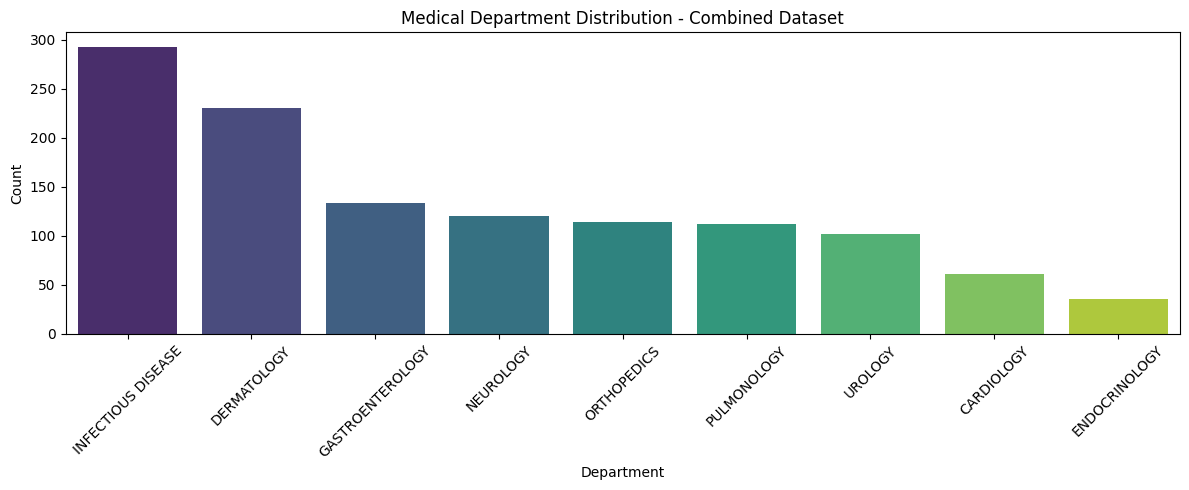

In [7]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df_combined, x='label',
              order=df_combined['label'].value_counts().index,
              palette='viridis')
plt.title('Medical Department Distribution - Combined Dataset')
plt.xlabel('Department')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

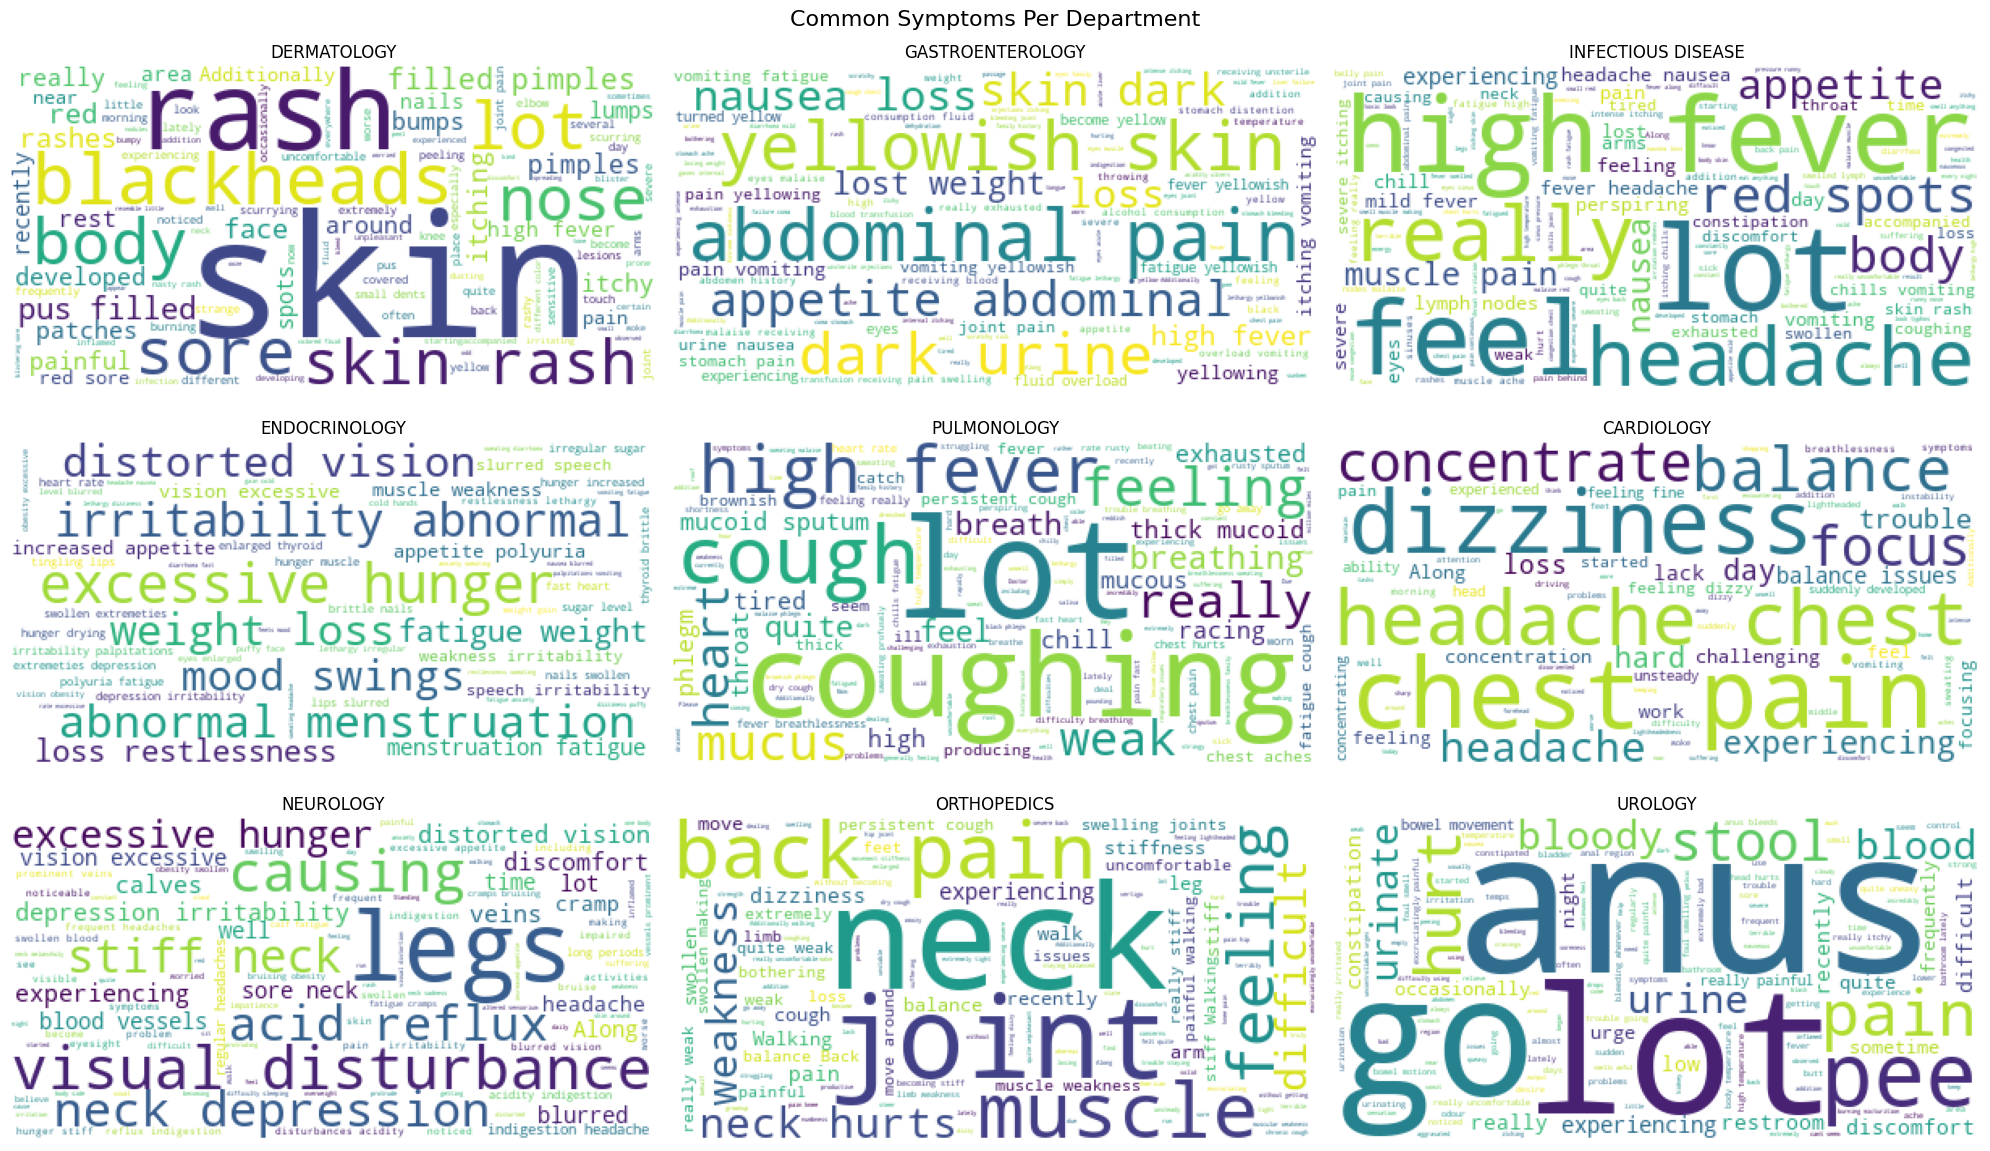

In [8]:
departments = df_combined['label'].unique()

plt.figure(figsize=(20, 12))
for i, dept in enumerate(departments):
    text = ' '.join(df_combined[df_combined['label'] == dept]['text'])
    wordcloud = WordCloud(width=400, height=200,
                         background_color='white').generate(text)
    plt.subplot(3, 3, i+1)
    plt.imshow(wordcloud)
    plt.axis('off')
    plt.title(dept)

plt.suptitle('Common Symptoms Per Department', fontsize=16)
plt.tight_layout()
plt.show()

In [9]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = text.replace('_', ' ')
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

df_combined['cleaned'] = df_combined['text'].apply(clean_text)

print("✅ Cleaning done!")
print("\nSample:")
print(df_combined[['text', 'cleaned']].head(3))

✅ Cleaning done!

Sample:
                                                text  \
0  itching skin rash nodal skin eruptions dischro...   
1  skin rash nodal skin eruptions dischromic  pat...   
2   itching nodal skin eruptions dischromic  patches   

                                             cleaned  
0  itching skin rash nodal skin eruptions dischro...  
1  skin rash nodal skin eruptions dischromic patches  
2    itching nodal skin eruptions dischromic patches  


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df_combined['cleaned']
y = df_combined['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("✅ Vectorization done!")
print("Train size:", X_train_tfidf.shape)
print("Test size:", X_test_tfidf.shape)

✅ Vectorization done!
Train size: (960, 2952)
Test size: (240, 2952)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("✅ Model trained!")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

✅ Model trained!
Accuracy: 0.9875

Classification Report:
                    precision    recall  f1-score   support

        CARDIOLOGY       1.00      1.00      1.00        12
       DERMATOLOGY       1.00      0.98      0.99        46
     ENDOCRINOLOGY       1.00      1.00      1.00         7
  GASTROENTEROLOGY       1.00      1.00      1.00        27
INFECTIOUS DISEASE       0.98      0.98      0.98        59
         NEUROLOGY       1.00      0.96      0.98        24
       ORTHOPEDICS       0.96      1.00      0.98        23
       PULMONOLOGY       0.96      1.00      0.98        22
           UROLOGY       1.00      1.00      1.00        20

          accuracy                           0.99       240
         macro avg       0.99      0.99      0.99       240
      weighted avg       0.99      0.99      0.99       240



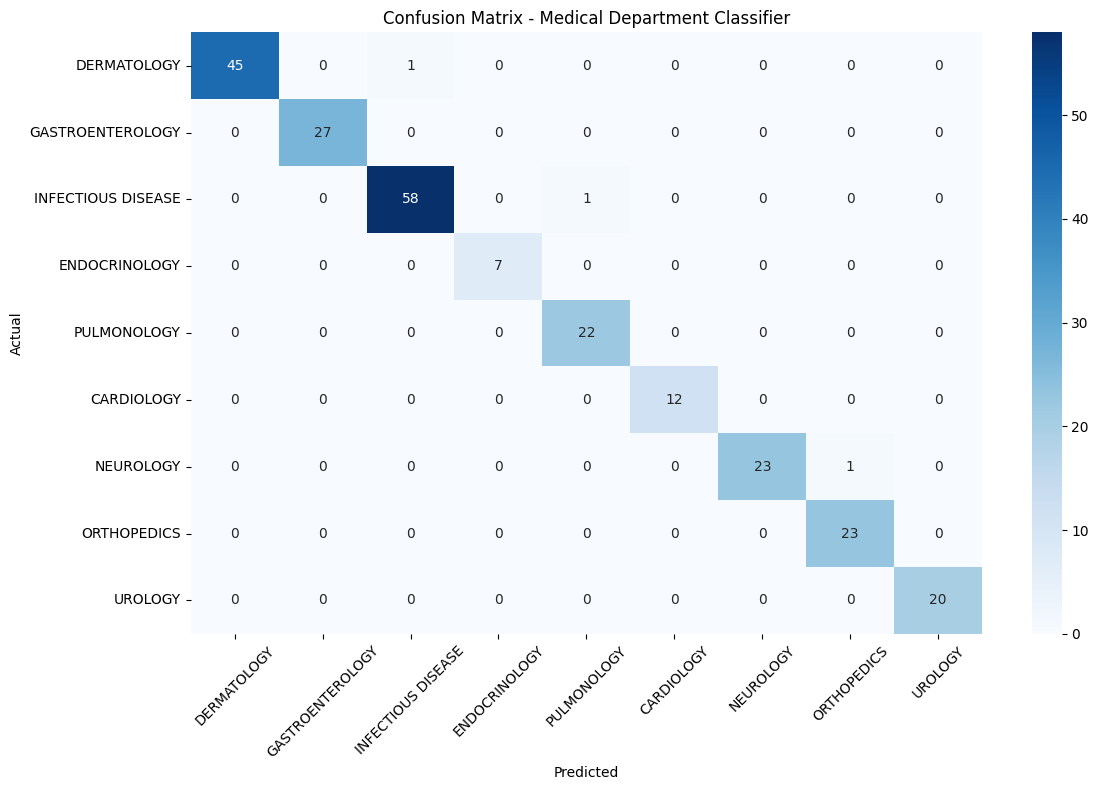

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred,
                      labels=df_combined['label'].unique())

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=df_combined['label'].unique(),
            yticklabels=df_combined['label'].unique())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Medical Department Classifier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
def predict_department(symptoms):
    cleaned = clean_text(symptoms)
    vectorized = tfidf.transform([cleaned])
    result = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    confidence = round(max(probability) * 100, 2)

    emojis = {
        'DERMATOLOGY': '🧴',
        'GASTROENTEROLOGY': '🍽️',
        'INFECTIOUS DISEASE': '🦠',
        'ENDOCRINOLOGY': '⚗️',
        'CARDIOLOGY': '❤️',
        'PULMONOLOGY': '🫁',
        'UROLOGY': '💧',
        'ORTHOPEDICS': '🦴',
        'NEUROLOGY': '🧠'
    }

    print(f"🔍 Symptoms: {symptoms}")
    print(f"{emojis[result]} Department: {result}")
    print(f"🎯 Confidence: {confidence}%")
    print("-" * 50)

# Interactive input
print("🏥 Medical Department Classifier")
print("=" * 50)
print("Type symptoms naturally with spaces")
print("Example: chest pain, joint pain, skin rash")
print("Type 'quit' to stop")
print("=" * 50)

while True:
    symptoms = input("\nEnter symptoms: ")
    if symptoms.lower() == 'quit':
        print("✅ Thank you for using Medical Department Classifier!")
        break
    if symptoms.strip() == '':
        print("⚠️ Please enter symptoms!")
        continue
    predict_department(symptoms)

🏥 Medical Department Classifier
Type symptoms naturally with spaces
Example: chest pain, joint pain, skin rash
Type 'quit' to stop
🔍 Symptoms: rash
🧴 Department: DERMATOLOGY
🎯 Confidence: 71.12%
--------------------------------------------------
✅ Thank you for using Medical Department Classifier!


In [17]:
import joblib
import os

# Make sure ml folder exists
os.makedirs('ml', exist_ok=True)

# Save model and tfidf
joblib.dump(model, 'ml/model.pkl')
joblib.dump(tfidf, 'ml/tfidf.pkl')

# Verify files are saved properly
model_size = os.path.getsize('ml/model.pkl')
tfidf_size = os.path.getsize('ml/tfidf.pkl')

print(f"✅ model.pkl saved! Size: {model_size} bytes")
print(f"✅ tfidf.pkl saved! Size: {tfidf_size} bytes")

✅ model.pkl saved! Size: 213727 bytes
✅ tfidf.pkl saved! Size: 123300 bytes
